In [3]:
from Bio.PDB import PDBList, PDBParser
from scipy.spatial import cKDTree
import numpy as np
from Bio.PDB import DSSP
from src.preprocessing.GraphBuilder import ProteinGraphBuilder

In [ ]:
import pandas as pd
data 

In [2]:
PDBList().download_pdb_files(['101M'], pdir='data/', file_format='pdb')


Structure exists: 'data/pdb101m.ent' 


In [3]:
data = ProteinGraphBuilder('./data/pdb101m.pdb').build()

[ProteinGraphBuilder] 154 residues | sequence length: 154
[ProteinGraphBuilder] No node features provided — using zeros.


/opt/miniconda3/envs/pytorch/lib/python3.10/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


In [ ]:
data

Data(x=[154, 1], edge_index=[2, 2254], edge_attr=[2254, 2], num_nodes=154)

In [7]:
data

Data(x=[154, 1], edge_index=[2, 2254], edge_attr=[2254])

In [9]:
ProteinGraphBuilder('./data/pdb101m.pdb').sequence

MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRVKHLKTEAEMKASEDLKKHGVTVLTALGAILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSRHPGNFGADAQGAMNKALELFRKDIAAKYKELGYQG


'MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRVKHLKTEAEMKASEDLKKHGVTVLTALGAILKKKGHHEAELKPLAQSHATKHKIPIKYLEFISEAIIHVLHSRHPGNFGADAQGAMNKALELFRKDIAAKYKELGYQG'

In [ ]:
import numpy as np
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser, DSSP, Selection
import torch
from torch_geometric.data import Data

VDW_CUTOFF = 8.0  
HBOND_ENERGY_THRESHOLD = -0.5 

class ProteinGraphBuilder:
    def __init__(self, pdb_path: str):
        self.pdb_path = pdb_path
        parser = PDBParser(QUIET=True)
        self.structure = parser.get_structure("protein", pdb_path)
        self.model = next(self.structure.get_models())
        self.residues = [
            r for r in Selection.unfold_entities(self.model, "R")
            if r.get_resname() != "HOH"  # exclude water
               and "CA" in r              # standard residues only
        ]
        self.res_to_idx = {r: i for i, r in enumerate(self.residues)}

    def _get_cb_coords(self) -> np.ndarray:
        coords = []
        for res in self.residues:
            atom = res["CB"] if "CB" in res else res["CA"]
            coords.append(atom.get_vector().get_array())
        return np.array(coords)

    def peptide_edges(self) -> list[tuple]:
        edges = []
        for i in range(len(self.residues) - 1):
            r1, r2 = self.residues[i], self.residues[i + 1]
            if r1.get_parent().id == r2.get_parent().id:  # same chain
                edges.append((i, i + 1, 1.0, "peptide"))
        return edges

    def vdw_edges(self) -> list[tuple]:
        cb = self._get_cb_coords()
        tree = cKDTree(cb)
        edges = []
        for i, j in tree.query_pairs(r=VDW_CUTOFF):
            dist = float(np.linalg.norm(cb[i] - cb[j]))
            weight = float(np.exp(-dist / VDW_CUTOFF))
            edges.append((i, j, weight, "vdw"))
        return edges

    def hbond_edges(self) -> list[tuple]:
        dssp = DSSP(self.model, self.pdb_path, dssp="mkdssp")
        edges = []
        dssp_keys = list(dssp.keys())
        
        for idx, key in enumerate(dssp_keys):
            data = dssp[key]
            for offset_field, energy_field in [(6, 7), (8, 9)]:
                offset = data[offset_field]
                energy = data[energy_field]
                if energy < HBOND_ENERGY_THRESHOLD and offset != 0:
                    partner_idx = idx + offset
                    if 0 <= partner_idx < len(dssp_keys):
                        edges.append((idx, partner_idx,
                                      float(abs(energy)), "hbond"))
        return edges

    def build(self) -> Data:
        all_edges = self.peptide_edges() + self.vdw_edges() + self.hbond_edges()
        
        src = torch.tensor([e[0] for e in all_edges], dtype=torch.long)
        dst = torch.tensor([e[1] for e in all_edges], dtype=torch.long)
        # Make undirected
        edge_index = torch.stack([
            torch.cat([src, dst]),
            torch.cat([dst, src])
        ])
        edge_weights = torch.tensor(
            [e[2] for e in all_edges] * 2, dtype=torch.float
        )
        # Placeholder node features — add yours here
        x = torch.zeros((len(self.residues), 1), dtype=torch.float)
        
        return Data(x=x, edge_index=edge_index, edge_attr=edge_weights)

In [77]:
data = ProteinGraphBuilder('./pdb101m.pdb').build()

[<Residue MET het=  resseq=0 icode= >, <Residue VAL het=  resseq=1 icode= >, <Residue LEU het=  resseq=2 icode= >, <Residue SER het=  resseq=3 icode= >, <Residue GLU het=  resseq=4 icode= >, <Residue GLY het=  resseq=5 icode= >, <Residue GLU het=  resseq=6 icode= >, <Residue TRP het=  resseq=7 icode= >, <Residue GLN het=  resseq=8 icode= >, <Residue LEU het=  resseq=9 icode= >, <Residue VAL het=  resseq=10 icode= >, <Residue LEU het=  resseq=11 icode= >, <Residue HIS het=  resseq=12 icode= >, <Residue VAL het=  resseq=13 icode= >, <Residue TRP het=  resseq=14 icode= >, <Residue ALA het=  resseq=15 icode= >, <Residue LYS het=  resseq=16 icode= >, <Residue VAL het=  resseq=17 icode= >, <Residue GLU het=  resseq=18 icode= >, <Residue ALA het=  resseq=19 icode= >, <Residue ASP het=  resseq=20 icode= >, <Residue VAL het=  resseq=21 icode= >, <Residue ALA het=  resseq=22 icode= >, <Residue GLY het=  resseq=23 icode= >, <Residue HIS het=  resseq=24 icode= >, <Residue GLY het=  resseq=25 icode

/opt/miniconda3/envs/pytorch/lib/python3.10/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)


In [155]:
data

Data(x=[154, 1], edge_index=[2, 2254], edge_attr=[2254])

In [29]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_graph(G, color):
    plt.figure(figsize=(15,9))
    plt.xticks([])
    plt.yticks([])
    edge_values = [attr[1] for _, _, attr in G.edges(data="edge_attr")]
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2", edge_color= edge_values)
    plt.title("Protein Graph Visualization")
    plt.show()

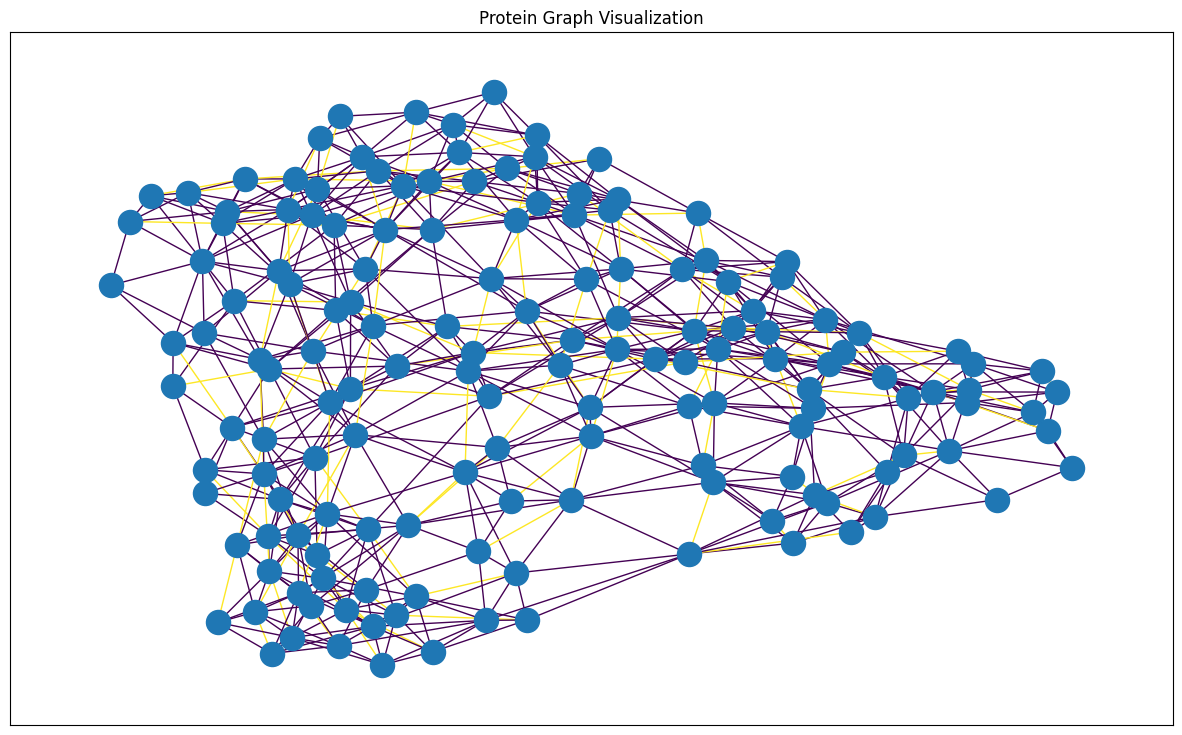

In [30]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True, edge_attrs=["edge_attr"])
visualize_graph(G, color=data.y)

In [81]:
data.edge_attr.t()

tensor([1.0000, 1.0000, 1.0000,  ..., 2.1000, 1.6000, 2.9000])

In [82]:
data.edge_index.t()

tensor([[  0,   1],
        [  1,   2],
        [  2,   3],
        ...,
        [145, 149],
        [147, 150],
        [146, 151]])

In [153]:
len(data.x)

154